# 实践一下子图

## 新api
- 

In [1]:
from typing import TypedDict


class Log(TypedDict):
    id: str
    question: str
    answer: str
    status: str
    latency: int
    error_type: str | None

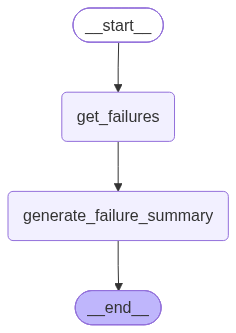

In [3]:

# 子图：失败分析
from langgraph.graph import END, START, StateGraph
from IPython.display import display, Image


class FailureAnalysisState(TypedDict):
    cleaned_logs: list[Log]
    failures: list[Log]
    fa_summary: str
    processed_logs: list[str]


# 子图输出状态
class FailureAnalysisOutputState(TypedDict):
    fa_summary: str
    processed_logs: list[str]


def get_failures(state: FailureAnalysisState):
    cleaned_logs = state["cleaned_logs"]
    failures = [log for log in cleaned_logs if log["status"] == "error"]

    return {"failures": failures}


def generate_failure_summary(state: FailureAnalysisState):
    failures = state["failures"]

    if not failures:
        summary = "没有发现错误日志"
    else:
        error_types = {}
        for log in failures:
            error_type = log.get("error_type", "unknown")
            error_types[error_type] = error_types.get(error_type, 0) + 1
        summary = f"发现{len(error_types)}个错误。"
        summary += f"错误类型分布：{error_types}"
    processed_logs = [
        f"failure-analysis-on-log-{failure['id']}" for failure in failures
    ]

    print("失败分析摘要生成完成")
    return {"fa_summary": summary, "processed_logs": processed_logs}

# 构建失败子图
fa_builder = StateGraph(state_schema=FailureAnalysisState, output_schema=FailureAnalysisOutputState)

fa_builder.add_node("get_failures", get_failures)
fa_builder.add_node("generate_failure_summary", generate_failure_summary)

fa_builder.add_edge(START,"get_failures")
fa_builder.add_edge("get_failures", "generate_failure_summary")
fa_builder.add_edge("generate_failure_summary",END)

fa_graph = fa_builder.compile()

display(Image(fa_graph.get_graph().draw_mermaid_png()))

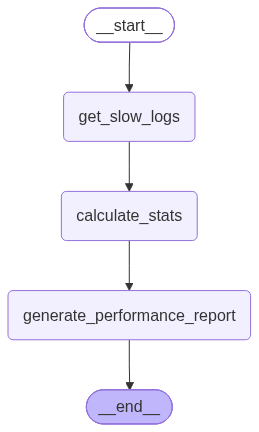

In [5]:
# 性能分析子图
class PerformanceAnalysisState(TypedDict):
    cleaned_logs: list[Log]
    slow_logs: list[Log]
    latency_stats: dict
    perf_report: str
    processed_logs: list[str]


class PerfornaceAnalysisOutputState(TypedDict):
    perf_report: str
    processed_logs: list[str]


def get_slow_logs(state: PerformanceAnalysisState) -> PerformanceAnalysisState:
    cleaned_logs = state["cleaned_logs"]
    slow_logs = [log for log in cleaned_logs if log.get("latency", 0) > 1000]

    print(f"找到{len(slow_logs)}条慢请求")
    return {"slow_logs": slow_logs}


def calculate_stats(state: PerformanceAnalysisState) -> PerformanceAnalysisState:
    slow_logs = state["slow_logs"]

    if slow_logs:
        latencies = [log["latency"] for log in slow_logs]
        stats = {
            "count": len(latencies),
            "avg": sum(latencies) / len(latencies),
            "max": max(latencies),
            "min": min(latencies),
        }
    else:
        stats = {"count": 0, "avg": 0, "max": 0, "min": 0}

    return {"latency_stats": stats}

def generate_performance_report(state:PerformanceAnalysisState):
    stats = state["latency_stats"]
    slow_logs = state["slow_logs"]

    report = f"性能报告：\n"
    report += f"- 慢请求数量: {stats['count']}\n"
    report += f"- 平均延迟: {stats['avg']:.0f}ms\n"
    report += f"- 最大延迟: {stats['max']}ms\n"
    report += f"- 最小延迟: {stats['min']}ms"
    # 记录处理的日志
    processed_logs = [
        f"performance-analysis-on-log-{log['id']}"
        for log in slow_logs
    ]

    print(f"📊 性能报告生成完成")
    return {
        "perf_report": report,
        "processed_logs": processed_logs
    }

pa_builder = StateGraph(PerformanceAnalysisState, output_schema=PerfornaceAnalysisOutputState)
pa_builder.add_node("get_slow_logs", get_slow_logs)
pa_builder.add_node("calculate_stats", calculate_stats)
pa_builder.add_node("generate_performance_report", generate_performance_report)

pa_builder.add_edge(START, "get_slow_logs")
pa_builder.add_edge("get_slow_logs","calculate_stats")
pa_builder.add_edge("calculate_stats","generate_performance_report")
pa_builder.add_edge("generate_performance_report", END)

pa_graph = pa_builder.compile()

display(Image(pa_graph.get_graph().draw_mermaid_png()))

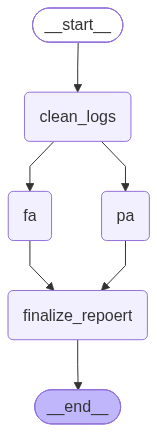

In [9]:
# 构建主图
import operator
from typing import Annotated

class MaingraphState(TypedDict):
    raw_logs: list[Log]
    cleaned_logs: list[Log]
    fa_summary: str
    perf_report: str
    processed_logs: Annotated[list[str], operator.add]
    final_output: str


def clean_logs(state: MaingraphState) -> MaingraphState:
    raw_logs = state["raw_logs"]

    cleaned_logs = [log for log in raw_logs if log.get("id")]
    print("日志清晰完成")
    return {"cleaned_logs": cleaned_logs}


def finalize_repoert(state: MaingraphState) -> MaingraphState:
    fa_summary = state.get("fa_summary", "wu")
    perf_report = state.get("perf_report", "wu")
    processed_logs = state.get("processed_logs", [])

    final_output = f"""
    {"=" * 50}
    📋 日志分析最终报告
    {"=" * 50}
    
    【失败分析】
    {fa_summary}
    
    【性能分析】
    {perf_report}
    
    【处理记录】
    共处理 {len(processed_logs)} 条日志:
    {chr(10).join(["  - " + log for log in processed_logs])}
    {"=" * 50}
    """

    print("✅ 最终报告生成完成")
    return {"final_output": final_output}


graph = StateGraph(MaingraphState)
graph.add_node("fa", fa_graph)
graph.add_node("pa", pa_graph)
graph.add_node("finalize_repoert",finalize_repoert)
graph.add_node("clean_logs",clean_logs)

graph.add_edge(START, "clean_logs")
graph.add_edge("clean_logs", "fa")
graph.add_edge("clean_logs", "pa")
graph.add_edge(["fa","pa"], "finalize_repoert")
graph.add_edge("finalize_repoert",END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
# ceshi
test_logs: list[Log] = [
        {
            "id": "1",
            "question": "How to use LangGraph?",
            "answer": "LangGraph is a framework for building AI applications.",
            "status": "success",
            "latency": 500,
            "error_type": None
        },
        {
            "id": "2",
            "question": "How to use Chroma?",
            "answer": "Error: Connection timeout",
            "status": "error",
            "latency": 5000,
            "error_type": "timeout"
        },
        {
            "id": "3",
            "question": "What is RAG?",
            "answer": "RAG stands for Retrieval Augmented Generation.",
            "status": "success",
            "latency": 300,
            "error_type": None
        },
        {
            "id": "4",
            "question": "How to build agents?",
            "answer": "Error: Rate limit exceeded",
            "status": "error",
            "latency": 2000,
            "error_type": "rate_limit"
        },
        {
            "id": "5",
            "question": "Explain state management",
            "answer": "State management in LangGraph uses TypedDict...",
            "status": "success",
            "latency": 1500,
            "error_type": None
        }
    ]

res = app.invoke({"raw_logs":test_logs})

日志清晰完成
失败分析摘要生成完成
找到3条慢请求
📊 性能报告生成完成
✅ 最终报告生成完成


In [11]:
print(res["final_output"])


    📋 日志分析最终报告

    【失败分析】
    发现2个错误。错误类型分布：{'timeout': 1, 'rate_limit': 1}

    【性能分析】
    性能报告：
- 慢请求数量: 3
- 平均延迟: 2833ms
- 最大延迟: 5000ms
- 最小延迟: 1500ms

    【处理记录】
    共处理 5 条日志:
      - failure-analysis-on-log-2
  - failure-analysis-on-log-4
  - performance-analysis-on-log-2
  - performance-analysis-on-log-4
  - performance-analysis-on-log-5
    
